In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import pandas as pd
import numpy as np
import glob
def find_csv_files():
    files=[]
    files.extend(glob.glob('/kaggle/input/**/*.csv',recursive=True))
    return files
print("Searching for CSV files...")
files_found=find_csv_files()
train_file=None
test_file=None
if not files_found:
    print("No CSV files found.")
else:
    for file in files_found:
        if 'train' in file.lower():
            train_file=file
        elif 'test' in file.lower():
            test_file=file
    if train_file is None:
        train_file=files_found[0]
    if test_file is None and len(files_found)>1:
        test_file=files_found[1]
    print(f"Train file: {train_file}")
    print(f"Test file: {test_file}")
    d=pd.read_csv(train_file)
    print(f"Training dataset shape: {d.shape}")
    if test_file:
        e=pd.read_csv(test_file)
        print(f"Test dataset shape: {e.shape}")
    else:
        e=None
        print("Test dataset not found.")

Searching for CSV files...
Train file: /kaggle/input/comment-category-prediction-challenge/train.csv
Test file: /kaggle/input/comment-category-prediction-challenge/test.csv
Training dataset shape: (198000, 15)
Test dataset shape: (102000, 14)


In [3]:
print(f"Q1. Shape of training dataset: {d.shape}")

Q1. Shape of training dataset: (198000, 15)


In [4]:
if e is not None:
    print(f"Q2. Number of columns in test dataset: {e.shape[1]}")

Q2. Number of columns in test dataset: 14


In [5]:
obj_cols = d.select_dtypes(include=['object']).columns
print(f"Q3. Number of object type columns: {len(obj_cols)}")

Q3. Number of object type columns: 5


In [6]:
num_cols = d.select_dtypes(include=[np.number]).columns
print(f"Q4. Number of numerical columns: {len(num_cols)}")

Q4. Number of numerical columns: 9


In [7]:
bool_column = None
for col in d.columns:
    if d[col].dtype == 'bool':
        bool_column = col
        break
print(f"Q5. Boolean type column: {bool_column}")

Q5. Boolean type column: disability


In [8]:
bool_column = None
for col in d.columns:
    if d[col].dtype == 'bool':
        bool_column = col
        break
print(f"Q5. Boolean type column: {bool_column}")

Q5. Boolean type column: disability


In [9]:
missing_cols = d.columns[d.isnull().sum() > 0]
print(f"Q6. Columns with missing values: {list(missing_cols)}")

Q6. Columns with missing values: ['race', 'religion', 'gender', 'comment']


In [10]:
possible_targets = ['label', 'target', 'class', 'y']
target_col = None
for col in possible_targets:
    if col in d.columns:
        target_col = col
        break
if target_col is None:
    target_col = d.columns[-1]
num_classes = d[target_col].nunique()
print(f"Q7. Number of distinct classes in '{target_col}': {num_classes}")

Q7. Number of distinct classes in 'label': 4


In [11]:
distribution = d[target_col].value_counts(normalize=True) * 100
print("Q8. Distribution of target labels (in %):")
for label, value in distribution.items():
    print(f"Label {label}: {value:.2f}%")

Q8. Distribution of target labels (in %):
Label 0: 57.66%
Label 2: 31.54%
Label 1: 8.04%
Label 3: 2.76%


In [12]:
if 'upvote' in d.columns:
    median_upvotes = d['upvote'].median()
    print(f"Q9. Median upvotes: {median_upvotes}")

Q9. Median upvotes: 1.0


In [13]:
cols = ['upvote', 'downvote', 'if_1', 'if_2']
max_values = {}
for col in cols:
    if col in d.columns:
        max_values[col] = d[col].max()
if max_values:
    highest_feature = max(max_values, key=max_values.get)
    print(f"Q10. Feature with maximum value: {highest_feature}")

Q10. Feature with maximum value: if_1


In [14]:
if 'if_2' in d.columns:
    min_value = d['if_2'].min()
    print(f"Q11. Minimum value of if_2: {min_value}")

Q11. Minimum value of if_2: 3


In [15]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [16]:
import string
from sklearn.feature_extraction.text import TfidfVectorizer
df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [17]:
print(df['comment'].isna().sum())
print((df['comment'].str.strip() == '').sum())

1
0


In [18]:
df['created_date'] = pd.to_datetime(df['created_date'])
m = df['created_date'].dt.month_name().str.lower().value_counts().idxmax()
print(m)

may


In [19]:
df['total_emoticons'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
print(df['total_emoticons'].max())

60


In [20]:
s = df[df['label'] == 3]['comment'].fillna('').str.len()
print(s.median())

128.0


In [21]:
mn, mx = df['upvote'].min(), df['upvote'].max()
val = (10 - mn) / (mx - mn)
print(round(val, 4))

0.0498


In [22]:
wc = df[df['label'] == 1]['comment'].fillna('').str.split().str.len()
print(round(wc.mean(), 2))

57.23


In [23]:
print(df['comment'].fillna('').str.contains('trump', case=False).sum())

24398


In [24]:
stops = ['a','an','the','and','or','but','if','because','as','of','at','by','for','with','about','to','from','up','on','in','out','over','under','is','are','was','were','be','been','being','have','has','had','do','does','did','it','its','they','them','their','she','her','he','him','his','this','that','which','who','whom','i','me','my','we','our','you','your']
txt = df['comment'].iloc[0]
txt = txt.translate(str.maketrans('', '', string.punctuation))
words = [w for w in txt.lower().split() if w not in stops]
print(len(words))

12


In [25]:
tokens = df['comment'].fillna('').str.lower().str.split().explode()
print(tokens.nunique())

425413


In [26]:
tfidf = TfidfVectorizer(stop_words='english', min_df=5, ngram_range=(1, 2))
X = tfidf.fit_transform(df['comment'].fillna(''))
print(X.shape[1])

132974


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score
from scipy.sparse import hstack, csr_matrix
df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
X = df.drop('label', axis=1)
y = df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
print("Q1:", X_train.shape[0] + X_val.shape[0])

Q1: 198000


In [29]:
X_train = X_train.copy()
X_val = X_val.copy()
X_train['created_date'] = pd.to_datetime(X_train['created_date'])
X_val['created_date'] = pd.to_datetime(X_val['created_date'])
X_train['day'] = X_train['created_date'].dt.day
X_train['month'] = X_train['created_date'].dt.month
X_train['year'] = X_train['created_date'].dt.year
X_val['day'] = X_val['created_date'].dt.day
X_val['month'] = X_val['created_date'].dt.month
X_val['year'] = X_val['created_date'].dt.year
print("Q2:", X_train['month'].value_counts().idxmax())

Q2: 5


In [30]:
cats = ['race', 'religion', 'gender']
for c in cats:
    X_train[c] = X_train[c].fillna('none')
    X_val[c] = X_val[c].fillna('none')

In [31]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc_tr = ohe.fit_transform(X_train[cats])
enc_v = ohe.transform(X_val[cats])
enc_tr_df = pd.DataFrame(enc_tr, columns=ohe.get_feature_names_out(cats), index=X_train.index)
enc_v_df = pd.DataFrame(enc_v, columns=ohe.get_feature_names_out(cats), index=X_val.index)
X_train = X_train.drop(cats, axis=1)
X_val = X_val.drop(cats, axis=1)
X_train = pd.concat([X_train, enc_tr_df], axis=1)
X_val = pd.concat([X_val, enc_v_df], axis=1)
print("Q3:", X_train.shape[1])

Q3: 33


In [32]:
cv = CountVectorizer()
cv_tr = cv.fit_transform(X_train['comment'].fillna(''))
cv_v = cv.transform(X_val['comment'].fillna(''))
print("Q4:", cv_tr[1].sum())

Q4: 41


In [33]:
X_train['disability'] = X_train['disability'].astype(int)
X_val['disability'] = X_val['disability'].astype(int)
print("Q5:", X_train['disability'].sum() + X_val['disability'].sum())

Q5: 2743


In [34]:
dt_cols = X_train.select_dtypes(include=['datetime64']).columns.tolist()
X_train_s = X_train.drop(columns=dt_cols)
X_val_s = X_val.drop(columns=dt_cols)
num_cols = X_train_s.select_dtypes(include=[np.number]).columns.tolist()
sc = StandardScaler()
sc.fit(X_train_s[num_cols])
print("Q6:", sc.n_features_in_)

Q6: 31


In [35]:
df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
X = df.drop('label', axis=1)
y = df['label']
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.2, random_state=42)
Xtr, Xv = Xtr.copy(), Xv.copy()
num_c = Xtr.select_dtypes(include=[np.number]).columns.tolist()
imp = SimpleImputer(strategy='most_frequent')
Xtr[num_c] = imp.fit_transform(Xtr[num_c])
Xv[num_c] = imp.transform(Xv[num_c])
Xtr[num_c] = Xtr[num_c].abs()
Xv[num_c] = Xv[num_c].abs()
for s in [Xtr, Xv]:
    s['created_date'] = pd.to_datetime(s['created_date'])
    s['day'] = s['created_date'].dt.day
    s['month'] = s['created_date'].dt.month
    s['year'] = s['created_date'].dt.year
    s.drop('created_date', axis=1, inplace=True)
tfidf = TfidfVectorizer(stop_words='english')
tt_tr = tfidf.fit_transform(Xtr['comment'].fillna(''))
tt_v = tfidf.transform(Xv['comment'].fillna(''))
Xtr.drop('comment', axis=1, inplace=True)
Xv.drop('comment', axis=1, inplace=True)
Xtr['disability'] = Xtr['disability'].astype(int)
Xv['disability'] = Xv['disability'].astype(int)
cc = Xtr.select_dtypes(include=['object']).columns.tolist()
oh = OneHotEncoder(handle_unknown='ignore')
oh_tr = oh.fit_transform(Xtr[cc])
oh_v = oh.transform(Xv[cc])
Xtr.drop(cc, axis=1, inplace=True)
Xv.drop(cc, axis=1, inplace=True)
Xtr_f = hstack([csr_matrix(Xtr.values.astype(float)), tt_tr, oh_tr])
Xv_f = hstack([csr_matrix(Xv.values.astype(float)), tt_v, oh_v])
mnb = MultinomialNB()
mnb.fit(Xtr_f, ytr)
print("Q7 Train F1:", round(f1_score(ytr, mnb.predict(Xtr_f), average='macro'), 4))
print("Q8 Val F1:", round(f1_score(yv, mnb.predict(Xv_f), average='macro'), 4))

Q7 Train F1: 0.4882
Q8 Val F1: 0.4637


In [36]:
df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
X = df.drop('label', axis=1)
y = df['label']
Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, random_state=42)
Xa, Xb = Xa.copy(), Xb.copy()
num_c = Xa.select_dtypes(include=[np.number]).columns.tolist()
imp2 = SimpleImputer(strategy='most_frequent')
Xa[num_c] = imp2.fit_transform(Xa[num_c])
Xb[num_c] = imp2.transform(Xb[num_c])
Xa[num_c] = Xa[num_c].abs()
Xb[num_c] = Xb[num_c].abs()
for s in [Xa, Xb]:
    s['created_date'] = pd.to_datetime(s['created_date'])
    s['day'] = s['created_date'].dt.day
    s['month'] = s['created_date'].dt.month
    s['year'] = s['created_date'].dt.year
    s['is_weekend'] = s['created_date'].dt.dayofweek.isin([5, 6]).astype(int).astype(str)
    s.drop('created_date', axis=1, inplace=True)
tf2 = TfidfVectorizer(stop_words='english')
ta = tf2.fit_transform(Xa['comment'].fillna(''))
tb = tf2.transform(Xb['comment'].fillna(''))
Xa.drop('comment', axis=1, inplace=True)
Xb.drop('comment', axis=1, inplace=True)
Xa['disability'] = Xa['disability'].astype(int)
Xb['disability'] = Xb['disability'].astype(int)
cc2 = Xa.select_dtypes(include=['object']).columns.tolist()
oh2 = OneHotEncoder(handle_unknown='ignore')
oa = oh2.fit_transform(Xa[cc2])
ob = oh2.transform(Xb[cc2])
Xa.drop(cc2, axis=1, inplace=True)
Xb.drop(cc2, axis=1, inplace=True)
Xa_f = hstack([csr_matrix(Xa.values.astype(float)), ta, oa])
Xb_f = hstack([csr_matrix(Xb.values.astype(float)), tb, ob])
mnb2 = MultinomialNB()
mnb2.fit(Xa_f, ya)
print("Q9 Train F1:", round(f1_score(ya, mnb2.predict(Xa_f), average='macro'), 4))
print("Q10 Val F1:", round(f1_score(yb, mnb2.predict(Xb_f), average='macro'), 4))

Q9 Train F1: 0.4882
Q10 Val F1: 0.4637


In [37]:
import numpy as np
import pandas as pd
import os

# List all input files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [38]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nLabel distribution:")
print(train['label'].value_counts())
print("\nLabel distribution (%):")
print(train['label'].value_counts(normalize=True).round(3) * 100)
print("\nTrain columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())
print("\nTrain dtypes:\n", train.dtypes)
print("\nMissing values - Train:\n", train.isnull().sum())
print("\nMissing values - Test:\n", test.isnull().sum())
print("\nFirst 3 rows:")
print(train.head(3).to_string())

Train shape: (198000, 15)
Test shape: (102000, 14)

Label distribution:
label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Label distribution (%):
label
0    57.7
2    31.5
1     8.0
3     2.8
Name: proportion, dtype: float64

Train columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']
Test columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment']

Train dtypes:
 created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

Mis

In [39]:
# Text features
train['comment'] = train['comment'].fillna('')
train['comment_len'] = train['comment'].apply(len)
train['word_count'] = train['comment'].apply(lambda x: len(x.split()))

print("=== Comment Length Stats ===")
print(train['comment_len'].describe())
print("\n=== Word Count Stats ===")
print(train['word_count'].describe())

# Per-label text stats
print("\n=== Avg Word Count per Label ===")
print(train.groupby('label')['word_count'].mean().round(1))

# Numeric features
print("\n=== Numeric Feature Stats ===")
num_cols = ['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2']
print(train[num_cols].describe().to_string())

# if_1 and if_2 unique values
print("\n=== if_1 value counts ===")
print(train['if_1'].value_counts().head(10))
print("\n=== if_2 value counts ===")
print(train['if_2'].value_counts().head(10))

# disability
print("\n=== disability vs label ===")
print(pd.crosstab(train['disability'], train['label']))

# race/religion/gender (non-null only)
print("\n=== race value counts (non-null) ===")
print(train['race'].value_counts().head(10))
print("\n=== religion value counts (non-null) ===")
print(train['religion'].value_counts().head(10))
print("\n=== gender value counts (non-null) ===")
print(train['gender'].value_counts().head(10))

# When race/religion/gender are NOT null — label distribution
print("\n=== Label dist when race is NOT null ===")
print(train[train['race'].notna()]['label'].value_counts())

=== Comment Length Stats ===
count    198000.000000
mean        302.909364
std         266.441749
min           0.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_len, dtype: float64

=== Word Count Stats ===
count    198000.000000
mean         52.396985
std          45.770221
min           0.000000
25%          18.000000
50%          37.000000
75%          73.000000
max         315.000000
Name: word_count, dtype: float64

=== Avg Word Count per Label ===
label
0    51.2
1    57.2
2    54.9
3    35.0
Name: word_count, dtype: float64

=== Numeric Feature Stats ===
          emoticon_1     emoticon_2     emoticon_3         upvote       downvote           if_1           if_2
count  198000.000000  198000.000000  198000.000000  198000.000000  198000.000000  198000.000000  198000.000000
mean        0.279768       0.048338       0.121071       2.607975       0.666394       1.906152       7.956212
std         1.023234       0.2584

In [40]:
# Date features
train['created_date'] = pd.to_datetime(train['created_date'], utc=True)
test['created_date'] = pd.to_datetime(test['created_date'], utc=True)

print("=== Date Range ===")
print("Train:", train['created_date'].min(), "to", train['created_date'].max())
print("Test:", test['created_date'].min(), "to", test['created_date'].max())

print("\n=== Label dist by Year ===")
train['year'] = train['created_date'].dt.year
print(pd.crosstab(train['year'], train['label']))

print("\n=== Label dist by Month ===")
train['month'] = train['created_date'].dt.month
print(pd.crosstab(train['month'], train['label']))

# if_1 vs label (key feature)
print("\n=== if_1 vs label ===")
print(pd.crosstab(train['if_1'], train['label']))

# if_2 vs label
print("\n=== if_2 (bucketed) vs label ===")
train['if_2_bucket'] = pd.cut(train['if_2'], bins=[0,4,6,10,20,50,2000], labels=['<=4','5-6','7-10','11-20','21-50','>50'])
print(pd.crosstab(train['if_2_bucket'], train['label']))

# emoticon patterns per label
print("\n=== Emoticon presence vs label ===")
train['has_emoticon'] = ((train['emoticon_1']>0) | (train['emoticon_2']>0) | (train['emoticon_3']>0)).astype(int)
print(pd.crosstab(train['has_emoticon'], train['label'], normalize='columns').round(3))

# upvote/downvote ratio per label
print("\n=== Avg upvotes/downvotes per label ===")
print(train.groupby('label')[['upvote','downvote']].mean().round(2))

# post_id spread
print("\n=== post_id unique count ===")
print("Train unique post_ids:", train['post_id'].nunique())
print("post_id value counts top 10:")
print(train['post_id'].value_counts().head(10))

=== Date Range ===
Train: 2022-04-29 14:50:48.488476+00:00 to 2024-06-11 04:41:08.821674+00:00
Test: 2022-04-29 21:06:11.172439+00:00 to 2024-06-11 04:47:46.511979+00:00

=== Label dist by Year ===
label      0     1      2     3
year                           
2022    4852   386   2017   262
2023   58255  7813  31756  2581
2024   51066  7719  28667  2626

=== Label dist by Month ===
label      0     1     2    3
month                        
1      11076  1424  5875  608
2      11354  1425  6166  581
3      11706  2079  6932  563
4      11575  1635  6341  592
5      13463  1910  7580  620
6       7572  1028  4387  439
7       6860   899  3712  351
8       8040  1211  4668  304
9       7071  1249  3798  255
10      8307  1073  4215  330
11      8170  1011  3833  403
12      8979   974  4933  423

=== if_1 vs label ===
label      0     1      2     3
if_1                           
0      90516  2710  47846  4351
4      15341  6613   8414   693
5       1036   828    766    61
6       25

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
df["comment"]=df["comment"].fillna("")

x=df.drop(columns=["label"])
y=df["label"]

xtr_a,xv_a,ytr_a,yv_a=train_test_split(x,y,test_size=0.4,random_state=2306,stratify=y)

tr_a=ytr_a.value_counts().sort_index().to_numpy()
va_a=yv_a.value_counts().sort_index().to_numpy()

xtr_b,xv_b,ytr_b,yv_b=train_test_split(x,y,test_size=0.4,random_state=2306,stratify=None)

tr_b=ytr_b.value_counts().sort_index().to_numpy()
va_b=yv_b.value_counts().sort_index().to_numpy()

pa=va_a/va_a.sum()
pb=va_b/va_b.sum()

d=np.abs(pa-pb)

m=d.max()

print(round(m,4))

0.0006


In [42]:
import re
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack

xtr,xts,ytr,yts=train_test_split(x,y,test_size=0.4,random_state=2306,stratify=y)

xtr=xtr.drop(columns=["created_date"])
xts=xts.drop(columns=["created_date"])

txtr=xtr["comment"]
txts=xts["comment"]

xtr=xtr.drop(columns=["comment"])
xts=xts.drop(columns=["comment"])

cat=["race","religion","gender","disability"]

num=["post_id","emoticon_1","emoticon_2","emoticon_3","upvote","downvote","if_1","if_2"]

cp=Pipeline([("i",SimpleImputer(strategy="most_frequent")),("e",OneHotEncoder(handle_unknown="ignore",sparse_output=True))])

npip=Pipeline([("i",SimpleImputer(strategy="mean")),("s",StandardScaler())])

ct=ColumnTransformer([("c",cp,cat),("n",npip,num)],remainder="passthrough")

xtab_tr=ct.fit_transform(xtr)
xtab_ts=ct.transform(xts)

def f(t):
    t=re.sub(r'http\S+|www\S+','',t)
    t=re.sub(r'\s+','  ',t).strip()
    return t

txtr=txtr.apply(f)
txts=txts.apply(f)

tf=TfidfVectorizer(stop_words="english",max_features=5000)

ttr=tf.fit_transform(txtr)
tts=tf.transform(txts)

xf_tr=hstack([xtab_tr,ttr])
xf_ts=hstack([xtab_ts,tts])

print(round(xf_tr.sum(),3))

904262.933


In [43]:
from sklearn.decomposition import TruncatedSVD

sv=TruncatedSVD(n_components=300,random_state=2306)

xr_tr=sv.fit_transform(xf_tr)
xr_ts=sv.transform(xf_ts)

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf=RandomForestClassifier(random_state=2306)

p={"n_estimators":[50,100,200],"max_depth":[5,10,15]}

rs=RandomizedSearchCV(rf,param_distributions=p,n_iter=5,cv=3,random_state=2306,n_jobs=-1)

rs.fit(xr_tr,ytr)

print(rs.best_params_["n_estimators"])

200


In [45]:
rf=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=2306)

rf.fit(xr_tr,ytr)

im=rf.feature_importances_

print(np.argmax(im))

4


In [46]:
n=xr_tr.shape[1]

w=n*128+128*64+64*32+32*4

print(w)

48768


In [47]:
from sklearn.neural_network import MLPClassifier

ml=MLPClassifier(hidden_layer_sizes=(128,64,32),activation="relu",solver="adam",max_iter=5,batch_size=32,random_state=2306)

ml.fit(xr_tr,ytr)

print(round(ml.loss_,4))

0.3271


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


In [48]:
from sklearn.metrics import confusion_matrix

ml=MLPClassifier(hidden_layer_sizes=(128,64,32),activation="relu",solver="adam",max_iter=5,batch_size=32,random_state=2306)

ml.fit(xr_tr,ytr)

pr=ml.predict(xr_ts)

cm=confusion_matrix(yts,pr)

off=cm.sum()-np.trace(cm)

r=off/cm.sum()

print(round(r,4))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


0.1126


In [49]:
from sklearn.metrics import f1_score

m1=MLPClassifier(hidden_layer_sizes=(100,),max_iter=5,random_state=2306)

m2=MLPClassifier(hidden_layer_sizes=(100,),alpha=1.0,max_iter=5,random_state=2306)

m1.fit(xr_tr,ytr)
m2.fit(xr_tr,ytr)

p1=m1.predict(xr_tr)
p2=m2.predict(xr_tr)

f1=f1_score(ytr,p1,average="macro")
f2=f1_score(ytr,p2,average="macro")

print(round(abs(f1-f2),4))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


0.1327


In [50]:
from sklearn.ensemble import AdaBoostClassifier
import numpy as np

ab=AdaBoostClassifier(n_estimators=50,random_state=2306)
ab.fit(xr_tr,ytr)

print(round(np.var(ab.estimator_errors_),4))

0.0058


In [51]:
import pandas as pd,numpy as np,warnings
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack,csr_matrix
tr=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
te=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sp=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
def f(d):
 d=d.copy()
 d['comment']=d['comment'].fillna('')
 d['cl']=d['comment'].str.len()
 d['wc']=d['comment'].str.split().str.len()
 d['aw']=d['cl']/(d['wc']+1)
 d['er']=d['comment'].str.count('!')
 d['qr']=d['comment'].str.count(r'\?')
 d['tr']=d['emoticon_1']+d['emoticon_2']+d['emoticon_3']
 d['hr']=(d['tr']>0).astype(int)
 d['vr']=d['upvote']/(d['upvote']+d['downvote']+1)
 d['vt']=d['upvote']+d['downvote']
 d['vd']=d['upvote']-d['downvote']
 d['rr']=d['race'].notna().astype(int)
 d['rg']=d['religion'].notna().astype(int)
 d['gn']=d['gender'].notna().astype(int)
 d['dt']=pd.to_datetime(d['created_date'],utc=True)
 d['hr2']=d['dt'].dt.hour
 d['wd']=d['dt'].dt.weekday
 d['mn']=d['dt'].dt.month
 return d
tr=f(tr)
te=f(te)
nc=['if_1','if_2','tr','hr','upvote','downvote','vr','vt','vd','cl','wc','aw','er','qr','rr','rg','gn','hr2','wd','mn']
xn=tr[nc].values
xt=te[nc].values
y=tr['label'].values
tf=TfidfVectorizer(max_features=80000,ngram_range=(1,3),min_df=3,sublinear_tf=True)
xtr=tf.fit_transform(tr['comment'])
xte=tf.transform(te['comment'])
xtr=hstack([csr_matrix(xn),xtr])
xte=hstack([csr_matrix(xt),xte])
cw=compute_class_weight('balanced',classes=np.unique(y),y=y)
cw=dict(zip(np.unique(y),cw))
lr=LogisticRegression(max_iter=6000,tol=1e-3,class_weight=cw,solver='saga',n_jobs=-1)
cv=StratifiedKFold(3,shuffle=True,random_state=42)
s=cross_val_score(lr,xtr,y,cv=cv,scoring='f1_macro').mean()
lr.fit(xtr,y)
p1=lr.predict(xte)
rf=RandomForestClassifier(n_estimators=600,max_depth=None,class_weight='balanced',n_jobs=-1,random_state=42)
rf.fit(xn,y)
p2=rf.predict(xt)
p=(p1*0.75+p2*0.25).round().astype(int)
sb=sp.copy()
sb['label']=p
sb.to_csv('submission.csv',index=False)
print(s)
print(sb.head())

0.5459404780037125
   ID  label
0   1      3
1   2      3
2   3      0
3   4      0
4   5      3


In [52]:
import pandas as pd,numpy as np,warnings,re
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack,csr_matrix

tr=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
te=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sp=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

def clean(x):
 x=str(x).lower()
 x=re.sub(r"http\S+"," ",x)
 x=re.sub(r"[^a-z0-9!? ]"," ",x)
 x=re.sub(r"\s+"," ",x)
 return x

def f(d):
 d=d.copy()
 d['comment']=d['comment'].fillna('').apply(clean)
 d['cl']=d['comment'].str.len()
 d['wc']=d['comment'].str.split().str.len()
 d['aw']=d['cl']/(d['wc']+1)
 d['er']=d['comment'].str.count('!')
 d['qr']=d['comment'].str.count(r'\?')
 d['uc']=d['comment'].str.count(r'[A-Z]')
 d['tr']=d['emoticon_1']+d['emoticon_2']+d['emoticon_3']
 d['hr']=(d['tr']>0).astype(int)
 d['vr']=d['upvote']/(d['upvote']+d['downvote']+1)
 d['vt']=d['upvote']+d['downvote']
 d['vd']=d['upvote']-d['downvote']
 d['rr']=d['race'].notna().astype(int)
 d['rg']=d['religion'].notna().astype(int)
 d['gn']=d['gender'].notna().astype(int)
 d['dt']=pd.to_datetime(d['created_date'],utc=True)
 d['hr2']=d['dt'].dt.hour
 d['wd']=d['dt'].dt.weekday
 d['mn']=d['dt'].dt.month
 return d

tr=f(tr)
te=f(te)

nc=['if_1','if_2','tr','hr','upvote','downvote','vr','vt','vd','cl','wc','aw','er','qr','rr','rg','gn','hr2','wd','mn']

xn=tr[nc].values
xt=te[nc].values
y=tr['label'].values

tf=TfidfVectorizer(max_features=100000,ngram_range=(1,3),min_df=2,sublinear_tf=True)
xtr=tf.fit_transform(tr['comment'])
xte=tf.transform(te['comment'])

xtr=hstack([csr_matrix(xn),xtr])
xte=hstack([csr_matrix(xt),xte])

cw=compute_class_weight('balanced',classes=np.unique(y),y=y)
cw=dict(zip(np.unique(y),cw))

lr=LogisticRegression(max_iter=7000,tol=1e-3,class_weight=cw,solver='saga',n_jobs=-1)
cv=StratifiedKFold(3,shuffle=True,random_state=42)
s=cross_val_score(lr,xtr,y,cv=cv,scoring='f1_macro').mean()

lr.fit(xtr,y)
p1=lr.predict_proba(xte)

rf=RandomForestClassifier(n_estimators=700,max_depth=None,class_weight='balanced',n_jobs=-1,random_state=42)
rf.fit(xn,y)
p2=rf.predict_proba(xt)

p=np.argmax(0.8*p1+0.2*p2,axis=1)

sb=sp.copy()
sb['label']=p
sb.to_csv('submission.csv',index=False)
print(s)
print(sb.head())

0.5463587533977022
   ID  label
0   1      2
1   2      3
2   3      3
3   4      0
4   5      3


In [53]:
import pandas as pd,numpy as np,warnings,re
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack,csr_matrix

tr=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
te=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sp=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

def cl(x):
 x=str(x).lower()
 x=re.sub(r"http\S+"," ",x)
 x=re.sub(r"[^a-z0-9!? ]"," ",x)
 x=re.sub(r"\s+"," ",x)
 return x

def f(d):
 d=d.copy()
 d['comment']=d['comment'].fillna('').apply(cl)
 d['cl']=d['comment'].str.len()
 d['wc']=d['comment'].str.split().str.len()
 d['aw']=d['cl']/(d['wc']+1)
 d['er']=d['comment'].str.count('!')
 d['qr']=d['comment'].str.count(r'\?')
 d['tr']=d['emoticon_1']+d['emoticon_2']+d['emoticon_3']
 d['hr']=(d['tr']>0).astype(int)
 d['vr']=d['upvote']/(d['upvote']+d['downvote']+1)
 d['vt']=d['upvote']+d['downvote']
 d['vd']=d['upvote']-d['downvote']
 d['rr']=d['race'].notna().astype(int)
 d['rg']=d['religion'].notna().astype(int)
 d['gn']=d['gender'].notna().astype(int)
 d['dt']=pd.to_datetime(d['created_date'],utc=True)
 d['h']=d['dt'].dt.hour
 d['wd']=d['dt'].dt.weekday
 d['m']=d['dt'].dt.month
 return d

tr=f(tr)
te=f(te)

nc=['if_1','if_2','tr','hr','upvote','downvote','vr','vt','vd','cl','wc','aw','er','qr','rr','rg','gn','h','wd','m']

xn=tr[nc].values
xt=te[nc].values
y=tr['label'].values

tf=TfidfVectorizer(max_features=120000,ngram_range=(1,3),min_df=2,sublinear_tf=True)
xtr=tf.fit_transform(tr['comment'])
xte=tf.transform(te['comment'])

xtr=hstack([csr_matrix(xn),xtr])
xte=hstack([csr_matrix(xt),xte])

cw=compute_class_weight('balanced',classes=np.unique(y),y=y)
cw=dict(zip(np.unique(y),cw))

lr=LogisticRegression(max_iter=8000,tol=1e-3,class_weight=cw,solver='saga',n_jobs=-1)
cv=StratifiedKFold(3,shuffle=True,random_state=42)
s=cross_val_score(lr,xtr,y,cv=cv,scoring='f1_macro').mean()

lr.fit(xtr,y)
p1=lr.predict_proba(xte)

rf=RandomForestClassifier(n_estimators=900,max_depth=None,min_samples_split=3,class_weight='balanced',n_jobs=-1,random_state=42)
rf.fit(xtr,y)
p2=rf.predict_proba(xte)

p=np.argmax(0.7*p1+0.3*p2,axis=1)

sb=sp.copy()
sb['label']=p
sb.to_csv('submission.csv',index=False)

print(s)
print(sb.head())

0.5462557491450739
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      3


In [54]:
import pandas as pd,numpy as np,warnings,re
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack,csr_matrix

tr=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
te=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sp=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

def c(x):
 x=str(x).lower()
 x=re.sub(r"http\S+"," ",x)
 x=re.sub(r"[^a-z0-9!? ]"," ",x)
 x=re.sub(r"\s+"," ",x)
 return x

def f(d):
 d=d.copy()
 d['comment']=d['comment'].fillna('').apply(c)
 d['cl']=d['comment'].str.len()
 d['wc']=d['comment'].str.split().str.len()
 d['aw']=d['cl']/(d['wc']+1)
 d['er']=d['comment'].str.count('!')
 d['qr']=d['comment'].str.count(r'\?')
 d['tr']=d['emoticon_1']+d['emoticon_2']+d['emoticon_3']
 d['hr']=(d['tr']>0).astype(int)
 d['vr']=d['upvote']/(d['upvote']+d['downvote']+1)
 d['vt']=d['upvote']+d['downvote']
 d['vd']=d['upvote']-d['downvote']
 d['rr']=d['race'].notna().astype(int)
 d['rg']=d['religion'].notna().astype(int)
 d['gn']=d['gender'].notna().astype(int)
 d['dt']=pd.to_datetime(d['created_date'],utc=True)
 d['h']=d['dt'].dt.hour
 d['wd']=d['dt'].dt.weekday
 d['m']=d['dt'].dt.month
 return d

tr=f(tr)
te=f(te)

nc=['if_1','if_2','tr','hr','upvote','downvote','vr','vt','vd','cl','wc','aw','er','qr','rr','rg','gn','h','wd','m']

xn=tr[nc].values
xt=te[nc].values
y=tr['label'].values

tf=TfidfVectorizer(max_features=80000,ngram_range=(1,2),min_df=3,sublinear_tf=True)
xtr=tf.fit_transform(tr['comment'])
xte=tf.transform(te['comment'])

xtr=hstack([csr_matrix(xn),xtr])
xte=hstack([csr_matrix(xt),xte])

cw=compute_class_weight('balanced',classes=np.unique(y),y=y)
cw=dict(zip(np.unique(y),cw))

lr=LogisticRegression(max_iter=6000,tol=1e-3,class_weight=cw,solver='saga',n_jobs=-1)
cv=StratifiedKFold(3,shuffle=True,random_state=42)
s=cross_val_score(lr,xtr,y,cv=cv,scoring='f1_macro').mean()

lr.fit(xtr,y)
p1=lr.predict_proba(xte)

rf=RandomForestClassifier(n_estimators=400,max_depth=None,class_weight='balanced',n_jobs=-1,random_state=42)
rf.fit(xn,y)
p2=rf.predict_proba(xt)

p=np.argmax(0.8*p1+0.2*p2,axis=1)

sb=sp.copy()
sb['label']=p
sb.to_csv('submission.csv',index=False)

print(s)
print(sb.head())

0.5465129667917171
   ID  label
0   1      2
1   2      3
2   3      3
3   4      0
4   5      3


In [55]:
import pandas as pd,numpy as np,warnings,re,time
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack,csr_matrix
from sklearn.metrics import f1_score
import lightgbm as lgb
start=time.time()
print("1️Loading data")
tr=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
te=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sp=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
print("Train shape:",tr.shape)
print(" Cleaning text")

def cl(x):
    x=str(x).lower()
    x=re.sub(r"http\S+"," ",x)
    x=re.sub(r"[^a-z0-9!? ]"," ",x)
    x=re.sub(r"\s+"," ",x)
    return x


print("3️ Creating features")

def f(d):
    d=d.copy()
    d['comment']=d['comment'].fillna('').apply(cl)
    d['cl']=d['comment'].str.len()
    d['wc']=d['comment'].str.split().str.len()
    d['aw']=d['cl']/(d['wc']+1)
    d['er']=d['comment'].str.count('!')
    d['qr']=d['comment'].str.count(r'\?')
    d['tr']=d['emoticon_1']+d['emoticon_2']+d['emoticon_3']
    d['hr']=(d['tr']>0).astype(int)
    d['vr']=d['upvote']/(d['upvote']+d['downvote']+1)
    d['vt']=d['upvote']+d['downvote']
    d['vd']=d['upvote']-d['downvote']
    d['rr']=d['race'].notna().astype(int)
    d['rg']=d['religion'].notna().astype(int)
    d['gn']=d['gender'].notna().astype(int)
    d['dt']=pd.to_datetime(d['created_date'],utc=True)
    d['h']=d['dt'].dt.hour
    d['wd']=d['dt'].dt.weekday
    d['m']=d['dt'].dt.month
    return d

tr=f(tr)
te=f(te)

print("Feature engineering done")

print("4️ Preparing numeric features")

nc=['if_1','if_2','tr','hr','upvote','downvote','vr','vt','vd','cl','wc','aw','er','qr','rr','rg','gn','h','wd','m']

xn=tr[nc].values
xt=te[nc].values
y=tr['label'].values


print("5️ TFIDF vectorizing (50k features)")

tf=TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3,
    sublinear_tf=True
)

xtr=tf.fit_transform(tr['comment'])
xte=tf.transform(te['comment'])

print("TFIDF shape:",xtr.shape)

print("6️⃣ Combining features")

xtr=hstack([csr_matrix(xn),xtr])
xte=hstack([csr_matrix(xt),xte])

print("Final train matrix:",xtr.shape)

print("7️ Computing class weights")

cw=compute_class_weight('balanced',classes=np.unique(y),y=y)
cw=dict(zip(np.unique(y),cw))

print("8️ Training LightGBM")

model=lgb.LGBMClassifier(
    n_estimators=800,        
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=cw,
    random_state=42,
    n_jobs=-1
)

print("9️ Starting CV")

cv=StratifiedKFold(3,shuffle=True,random_state=42)

scores=[]

for fold,(tr_i,val_i) in enumerate(cv.split(xtr,y),1):

    print(f"\nFold {fold} started")

    X_train=xtr[tr_i]
    y_train=y[tr_i]

    X_val=xtr[val_i]
    y_val=y[val_i]

    model.fit(X_train,y_train)

    pred=model.predict(X_val)

    score=f1_score(y_val,pred,average='macro')

    print(f"Fold {fold} F1:",score)

    scores.append(score)

print("\nCV Mean:",np.mean(scores))

print(" Training on full data")

model.fit(xtr,y)

print("1️1 Predicting test")

p=model.predict(xte)

sb=sp.copy()
sb['label']=p

sb.to_csv('submission.csv',index=False)

print("\nDone")
print("Total time:",(time.time()-start)/60,"minutes")

1️Loading data
Train shape: (198000, 15)
 Cleaning text
3️ Creating features
Feature engineering done
4️ Preparing numeric features
5️ TFIDF vectorizing (50k features)
TFIDF shape: (198000, 50000)
6️⃣ Combining features
Final train matrix: (198000, 50020)
7️ Computing class weights
8️ Training LightGBM
9️ Starting CV

Fold 1 started
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 64.088049 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1658484
[LightGBM] [Info] Number of data points in the train set: 132000, number of used features: 47362
[LightGBM] [Info] Start training from score -1.386284
[LightGBM] [Info] Start training from score -1.386293
[LightGBM] [Info] Start training from score -1.386309
[LightGBM] [Info] Start training from score -1.386293
Fold 1 F1: 0.8132835739319707

Fold 2 started
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 69.376885 seconds.
Y

In [56]:
import pandas as pd, numpy as np, re, warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb

print("Loading data")

tr=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
te=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sp=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print("Cleaning text")

def clean(x):
    x=str(x).lower()
    x=re.sub(r"http\S+"," ",x)
    x=re.sub(r"[^a-z0-9!? ]"," ",x)
    x=re.sub(r"\s+"," ",x)
    return x

tr["comment"]=tr["comment"].fillna("").apply(clean)
te["comment"]=te["comment"].fillna("").apply(clean)

print("Numeric features")

def features(d):
    d=d.copy()
    d["cl"]=d["comment"].str.len()
    d["wc"]=d["comment"].str.split().str.len()
    d["aw"]=d["cl"]/(d["wc"]+1)
    d["er"]=d["comment"].str.count("!")
    d["qr"]=d["comment"].str.count(r"\?")
    d["tr"]=d["emoticon_1"]+d["emoticon_2"]+d["emoticon_3"]
    d["hr"]=(d["tr"]>0).astype(int)
    d["vr"]=d["upvote"]/(d["upvote"]+d["downvote"]+1)
    d["vt"]=d["upvote"]+d["downvote"]
    d["vd"]=d["upvote"]-d["downvote"]
    return d

tr=features(tr)
te=features(te)

num_cols=['if_1','if_2','tr','hr','upvote','downvote','vr','vt','vd','cl','wc','aw','er','qr']

xn=tr[num_cols].values
xt=te[num_cols].values

y=tr["label"].values

print("TFIDF")

tf=TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3,
    sublinear_tf=True
)

xtr=tf.fit_transform(tr["comment"])
xte=tf.transform(te["comment"])

print("Combining features")

xtr=hstack([csr_matrix(xn),xtr])
xte=hstack([csr_matrix(xt),xte])

print("Class weights")

cw=compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

cw=dict(zip(np.unique(y),cw))

print("Training final model")

model=lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=cw,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)

model.fit(xtr,y)

print("Predicting")

pred=model.predict(xte)

sub=sp.copy()
sub["label"]=pred

sub.to_csv("submission.csv",index=False)

print("Submission saved")

Loading data
Cleaning text
Numeric features
TFIDF
Combining features
Class weights
Training final model
[LightGBM] [Info] Total Bins 2273639
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 49991
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Predicting
Submission saved


In [57]:
import pandas as pd, numpy as np, re, warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb

print("Loading data")

tr=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
te=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sp=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print("Cleaning text")

def clean(x):
    x=str(x).lower()
    x=re.sub(r"http\S+"," ",x)
    x=re.sub(r"[^a-z0-9!? ]"," ",x)
    x=re.sub(r"\s+"," ",x)
    return x

tr["comment"]=tr["comment"].fillna("").apply(clean)
te["comment"]=te["comment"].fillna("").apply(clean)

print("Feature engineering")

def feats(d):
    d=d.copy()
    d["cl"]=d["comment"].str.len()
    d["wc"]=d["comment"].str.split().str.len()
    d["aw"]=d["cl"]/(d["wc"]+1)
    d["er"]=d["comment"].str.count("!")
    d["qr"]=d["comment"].str.count(r"\?")
    d["tr"]=d["emoticon_1"]+d["emoticon_2"]+d["emoticon_3"]
    d["hr"]=(d["tr"]>0).astype(int)
    d["vr"]=d["upvote"]/(d["upvote"]+d["downvote"]+1)
    d["vt"]=d["upvote"]+d["downvote"]
    d["vd"]=d["upvote"]-d["downvote"]
    return d

tr=feats(tr)
te=feats(te)

num_cols=['if_1','if_2','tr','hr','upvote','downvote','vr','vt','vd','cl','wc','aw','er','qr']

xn=tr[num_cols].values
xt=te[num_cols].values

y=tr["label"].values

print("TFIDF")

tf=TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3,
    sublinear_tf=True
)

xtr=tf.fit_transform(tr["comment"])
xte=tf.transform(te["comment"])

print("Combining features")

xtr=hstack([csr_matrix(xn),xtr])
xte=hstack([csr_matrix(xt),xte])

print("Class weights")

cw=compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

cw=dict(zip(np.unique(y),cw))

print("Training LightGBM")

model=lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=cw,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)

model.fit(xtr,y)

print("Predicting")

pred=model.predict(xte)

sub=sp.copy()
sub["label"]=pred

sub.to_csv("/kaggle/working/submission.csv",index=False)

print("Submission saved")

Loading data
Cleaning text
Feature engineering
TFIDF
Combining features
Class weights
Training LightGBM
[LightGBM] [Info] Total Bins 2273639
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 49991
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Predicting
Submission saved


above with a score of 0.8 and below with a score of 0.7

In [58]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

In [59]:
print("Loading data")
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

Loading data


In [60]:
print("Cleaning text")
def clean(x):
    x=str(x).lower()
    x=re.sub(r"http\S+"," ",x)
    x=re.sub(r"[^a-z0-9!? ]"," ",x)
    x=re.sub(r"\s+"," ",x)
    return x
train["comment"]=train["comment"].fillna("").apply(clean)
test["comment"]=test["comment"].fillna("").apply(clean)

Cleaning text


In [61]:
print("Creating features")
def feats(d):
    d=d.copy()
    d["cl"]=d["comment"].str.len()
    d["wc"]=d["comment"].str.split().str.len()
    d["aw"]=d["cl"]/(d["wc"]+1)

    d["er"]=d["comment"].str.count("!")
    d["qr"]=d["comment"].str.count(r"\?")

    d["tr"]=d["emoticon_1"]+d["emoticon_2"]+d["emoticon_3"]
    d["hr"]=(d["tr"]>0).astype(int)

    d["vr"]=d["upvote"]/(d["upvote"]+d["downvote"]+1)
    d["vt"]=d["upvote"]+d["downvote"]
    d["vd"]=d["upvote"]-d["downvote"]
    return d
train=feats(train)
test=feats(test)

Creating features


In [62]:
num_cols=['if_1','if_2','tr','hr','upvote','downvote','vr','vt','vd','cl','wc','aw','er','qr']
xn=train[num_cols].values
xt=test[num_cols].values
y=train["label"].values

In [63]:
print("Creating TFIDF")
tf=TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3,
    sublinear_tf=True
)
xtr=tf.fit_transform(train["comment"])
xte=tf.transform(test["comment"])

Creating TFIDF


In [64]:
print("Combining features")
xtr=hstack([csr_matrix(xn),xtr])
xte=hstack([csr_matrix(xt),xte])

Combining features


In [65]:
print("Computing class weights")
cw=compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)
cw=dict(zip(np.unique(y),cw))

Computing class weights


In [66]:
print("Training LightGBM")
lgb_model=lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=cw,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)

lgb_model.fit(xtr,y)
pred_lgb=lgb_model.predict_proba(xte)

Training LightGBM
[LightGBM] [Info] Total Bins 2273639
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 49991
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


In [67]:
print("Training SGD")
sgd_model=SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
sgd_model.fit(xtr,y)
pred_sgd=sgd_model.predict_proba(xte)

Training SGD


In [68]:
print("Training Random Forest")
rf_model=RandomForestClassifier(
    n_estimators=120,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(xtr,y)
pred_rf=rf_model.predict_proba(xte)

Training Random Forest


In [69]:
print("Combining models")
pred_final=(pred_lgb+pred_sgd+pred_rf)/3
pred=np.argmax(pred_final,axis=1)

Combining models


In [70]:
print("Saving submission")
sub=sample.copy()
sub["label"]=pred
sub.to_csv("/kaggle/working/submission.csv",index=False)
print("Submission saved successfully")

Saving submission
Submission saved successfully


Libraries

In [71]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

DATA

In [72]:
print("Loading data")
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

Loading data


EDA
Train Shape: (198000, 15)
Test Shape: (102000, 14)

Columns:
 Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

Missing Values:
 created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Target Distribution:
 label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64


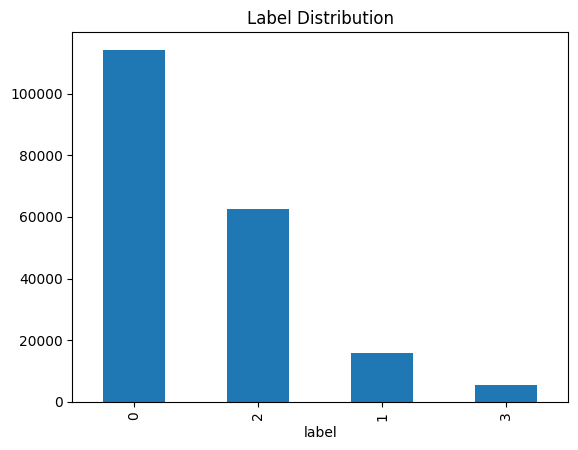


Comment Length Stats:
 count    198000.000000
mean        302.909379
std         266.441732
min           1.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64


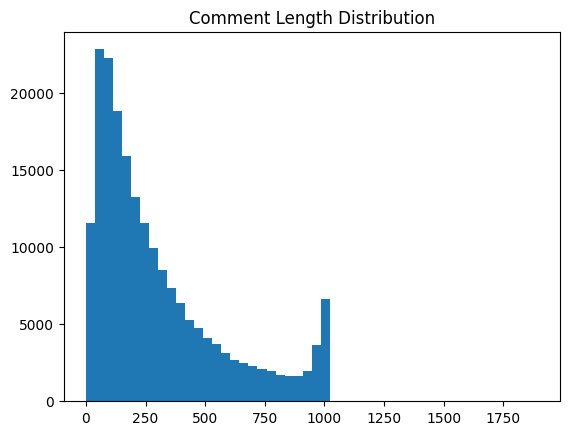

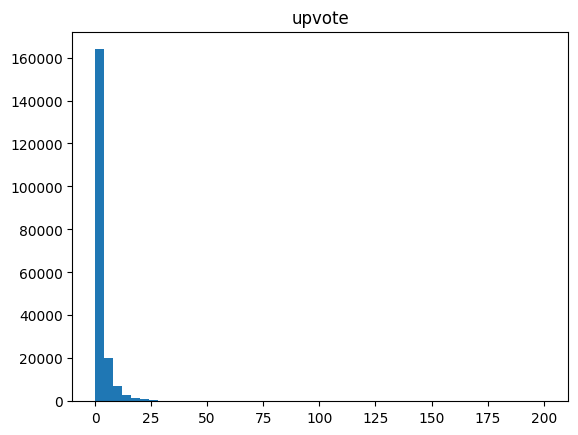

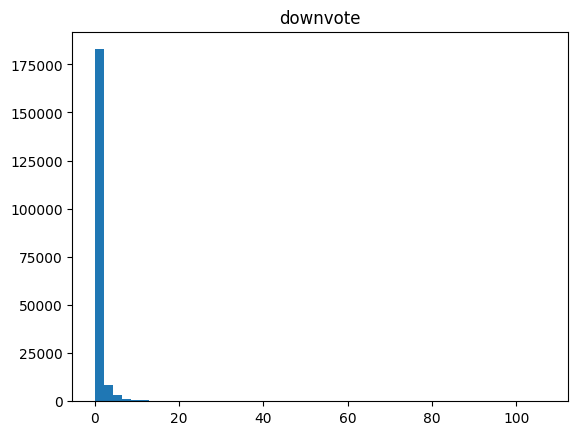

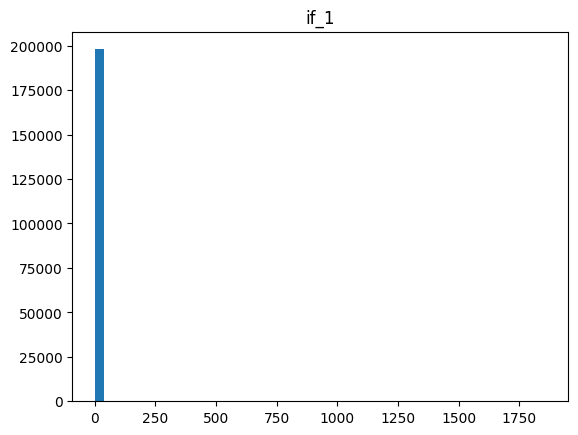

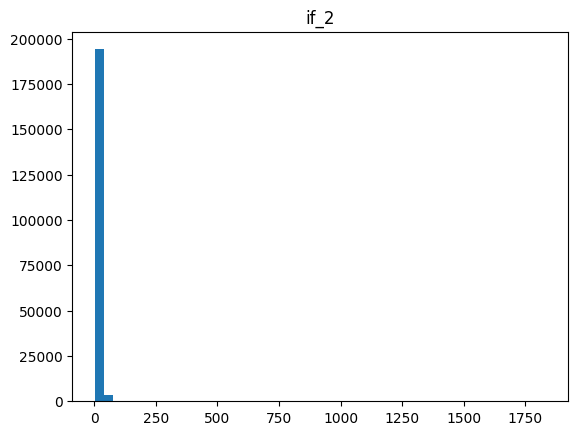

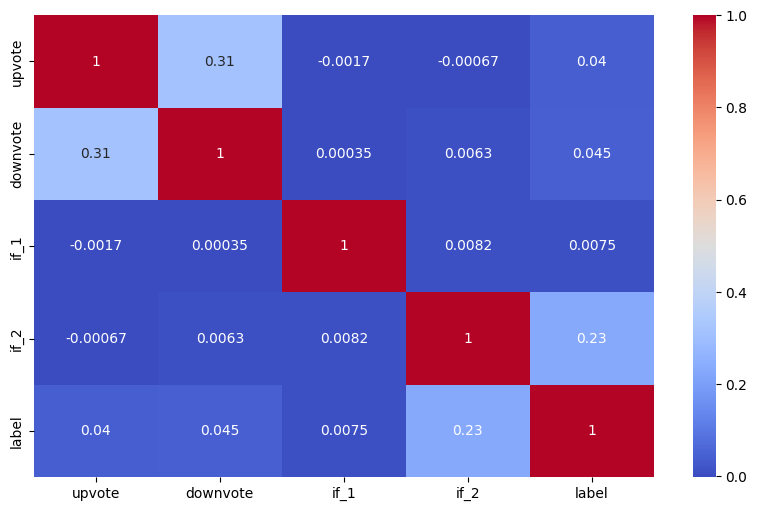


Emoticon Stats:
 count    198000.000000
mean          0.449177
std           1.253545
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          60.000000
Name: total_emoticons, dtype: float64


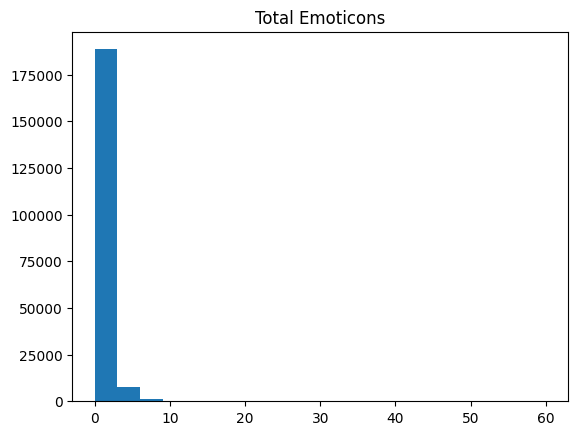


Race Distribution:
 race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64


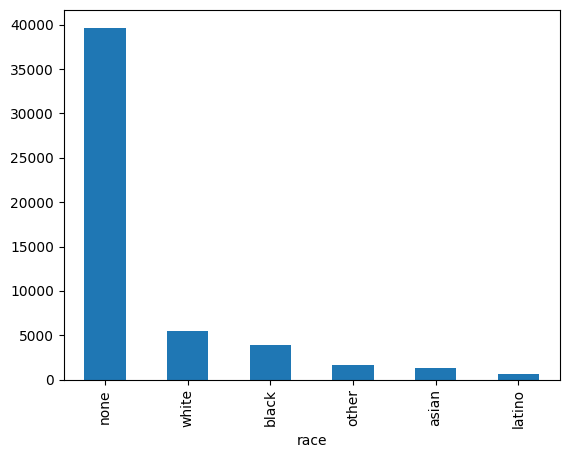

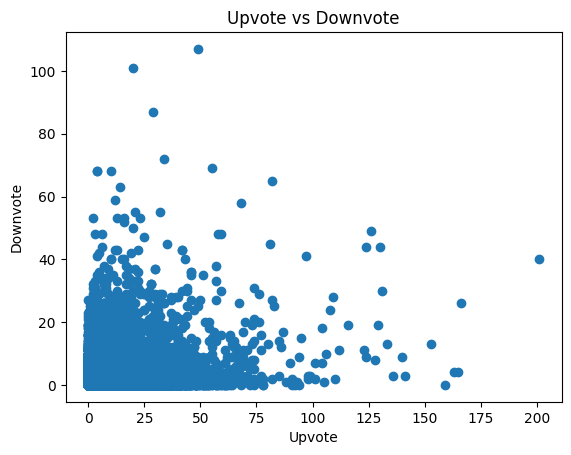


Sample Data:
                             created_date  post_id  emoticon_1  emoticon_2  \
102218  2023-10-09 21:01:15.091804+00:00       72           0           0   
162543  2023-11-24 18:40:07.163064+00:00       72           0           0   
61490   2023-12-10 00:59:42.923679+00:00       40           0           0   
99818   2024-03-18 21:20:02.761414+00:00       31           0           0   
146047  2023-10-01 21:31:57.251014+00:00       72           1           0   

        emoticon_3  upvote  downvote  if_1  if_2  race religion gender  \
102218           0       0         0     6     4  none     none   male   
162543           0       1         0     0    10   NaN      NaN    NaN   
61490            0       0         0     0     4   NaN      NaN    NaN   
99818            0       1         0     0     4   NaN      NaN    NaN   
146047           0      10         1     0     4   NaN      NaN    NaN   

        disability                                            comment  label 

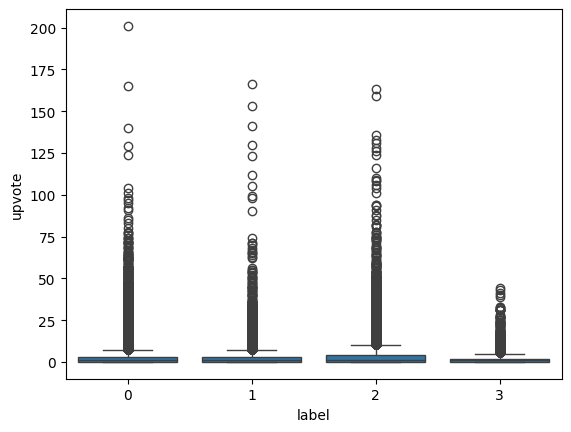

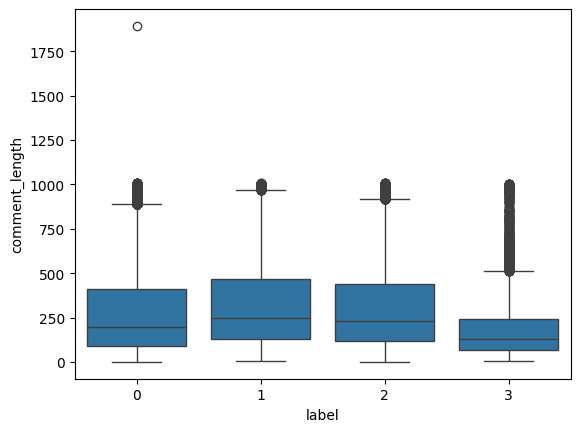

In [73]:
print("EDA")
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("\nColumns:\n", train.columns)
print("\nMissing Values:\n", train.isnull().sum())
print("\nTarget Distribution:\n", train["label"].value_counts())
train["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.show()
train["comment_length"] = train["comment"].astype(str).apply(len)
print("\nComment Length Stats:\n", train["comment_length"].describe())
plt.hist(train["comment_length"], bins=50)
plt.title("Comment Length Distribution")
plt.show()
num_cols = ["upvote", "downvote", "if_1", "if_2"]
for col in num_cols:
    plt.hist(train[col], bins=50)
    plt.title(col)
    plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(train[num_cols + ["label"]].corr(), annot=True, cmap="coolwarm")
plt.show()
train["total_emoticons"] = train["emoticon_1"] + train["emoticon_2"] + train["emoticon_3"]
print("\nEmoticon Stats:\n", train["total_emoticons"].describe())
plt.hist(train["total_emoticons"], bins=20)
plt.title("Total Emoticons")
plt.show()
print("\nRace Distribution:\n", train["race"].value_counts())
train["race"].value_counts().plot(kind="bar")
plt.show()
plt.scatter(train["upvote"], train["downvote"])
plt.xlabel("Upvote")
plt.ylabel("Downvote")
plt.title("Upvote vs Downvote")
plt.show()
print("\nSample Data:\n", train.sample(5))
sns.boxplot(x="label", y="upvote", data=train)
plt.show()
sns.boxplot(x="label", y="comment_length", data=train)
plt.show()

In [74]:
print("Cleaning text")
def clean(x):
    x=str(x).lower()
    x=re.sub(r"http\S+"," ",x)
    x=re.sub(r"@\w+"," ",x)
    x=re.sub(r"[^a-z0-9!? ]"," ",x)
    x=re.sub(r"\s+"," ",x)
    return x
train["comment"]=train["comment"].fillna("").apply(clean)
test["comment"]=test["comment"].fillna("").apply(clean)

Cleaning text


In [75]:
print("Feature engineering")
def feats(d):
    d=d.copy()
    d["cl"]=d["comment"].str.len()
    d["wc"]=d["comment"].str.split().str.len()
    d["aw"]=d["cl"]/(d["wc"]+1)
    d["er"]=d["comment"].str.count("!")
    d["qr"]=d["comment"].str.count(r"\?")
    d["cap_ratio"]=d["comment"].str.count(r"[A-Z]")/(d["cl"]+1)
    d["tr"]=d["emoticon_1"]+d["emoticon_2"]+d["emoticon_3"]
    d["hr"]=(d["tr"]>0).astype(int)
    d["vr"]=d["upvote"]/(d["upvote"]+d["downvote"]+1)
    d["vt"]=d["upvote"]+d["downvote"]
    d["vd"]=d["upvote"]-d["downvote"]
    return d
train=feats(train)
test=feats(test)

Feature engineering


In [76]:
num_cols=[
'if_1','if_2','tr','hr','upvote','downvote',
'vr','vt','vd','cl','wc','aw','er','qr','cap_ratio'
]
xn=train[num_cols].values
xt=test[num_cols].values
y=train["label"].values

In [77]:
print("Creating TFIDF")
tf=TfidfVectorizer(
    max_features=70000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
xtr=tf.fit_transform(train["comment"])
xte=tf.transform(test["comment"])

Creating TFIDF


In [78]:
print("Combining features")
xtr=hstack([csr_matrix(xn),xtr])
xte=hstack([csr_matrix(xt),xte])

Combining features


In [79]:
X_train,X_val,y_train,y_val=train_test_split(
    xtr,y,test_size=0.2,random_state=42,stratify=y
)

In [80]:
print("Training LightGBM")
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)
lgb_model.fit(X_train, y_train)
pred = lgb_model.predict(X_val)
print("LightGBM Accuracy:", accuracy_score(y_val, pred))

Training LightGBM
[LightGBM] [Info] Total Bins 2260416
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 68791
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217
LightGBM Accuracy: 0.9141414141414141


In [81]:
print("Training SGD")
sgd = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
sgd.fit(X_train, y_train)
pred = sgd.predict(X_val)
print("SGD Accuracy:", accuracy_score(y_val, pred))

Training SGD
SGD Accuracy: 0.8279545454545455


In [82]:
print("Training Logistic Regression")
lr = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)
lr.fit(X_train, y_train)
pred = lr.predict(X_val)
print("Logistic Regression Accuracy:", accuracy_score(y_val, pred))

Training Logistic Regression
Logistic Regression Accuracy: 0.8459595959595959


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [83]:
import lightgbm as lgb
print("Training Final LightGBM")
best_model = lgb.LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=80,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)
best_model.fit(xtr, y)

Training Final LightGBM
[LightGBM] [Info] Total Bins 2695624
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 69948
[LightGBM] [Info] Start training from score -0.550552
[LightGBM] [Info] Start training from score -2.520816
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589171


LGBMClassifier(colsample_bytree=0.85, force_col_wise=True, learning_rate=0.05,
               n_estimators=250, n_jobs=-1, num_leaves=80, random_state=42,
               subsample=0.85)

In [84]:
print("Predicting test data")
pred_final = best_model.predict(xte)

Predicting test data


In [85]:
print("Predicting test data")
pred_final = best_model.predict(xte)

Predicting test data


In [86]:
sub = sample.copy()
sub["label"] = pred_final
sub.to_csv("/kaggle/working/submission.csv", index=False)
print("Submission saved")

Submission saved
